In [ ]:
import pandas as pd
# from sklearn.feature_extraction.text import TfidfVectorizer
from cuml.feature_extraction.text import TfidfVectorizer
import numpy as np

In [ ]:
input_file = "../data/train_20251216.csv"

df = pd.read_csv(input_file)

df.columns

In [ ]:
import spacy
nlp = spacy.load("en_core_web_lg")

documents = nlp.pipe(df['title'])
doc_vbs = [" ".join([t.text for t in doc if t.pos_=='VERB']) for doc in documents]
df['title_vb'] = pd.Series(doc_vbs)
df['title_vb']

In [ ]:
documents = nlp.pipe(df['first_para'])
doc_vbs = [" ".join([t.text for t in doc if t.pos_=='VERB']) for doc in documents]
df['first_para_vb'] = pd.Series(doc_vbs)
df['first_para_vb']

In [130]:
tfidf = TfidfVectorizer(
    dtype=np.float32,
    stop_words='english',
    max_df=0.7,
    max_features=50
)
x_tfidf = tfidf.fit_transform(df['title']).toarray().get()

In [131]:
tfidf.get_feature_names()

0              attack
1               biden
2          california
3               calls
4                case
5                 ceo
6     charlottesville
7                city
8            colorado
9               court
10                day
11               dead
12              death
13             donald
14            florida
15             helene
16               help
17               home
18              house
19          hurricane
20             israel
21              judge
22             killed
23               know
24                man
25              money
26                new
27               news
28                 ny
29                nyc
30            orlando
31             people
32             police
33          president
34                say
35               says
36           shooting
37              state
38            suspect
39             terror
40              trial
41              trump
42            victims
43           violence
44           virginia
45        

In [132]:
# from cuml.manifold import TSNE
from sklearn.decomposition import PCA

print(x_tfidf.shape)

# x_2d = TSNE(n_components=2, metric='cosine', perplexity=50, n_neighbors=200).fit_transform(x_tfidf)
x_2d = PCA(n_components=2).fit_transform(x_tfidf)
# x_2d = LocallyLinearEmbedding(n_components=2, n_jobs=-1).fit_transform(x_tfidf)

events = df['EventLabel']
data = {
    "x": x_2d[:, 0],
    "y": x_2d[:, 1],
    "event": events,
    
}

(37913, 50)


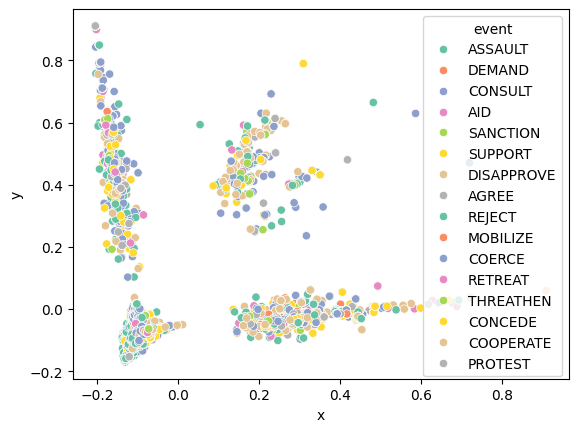

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data, x='x', y='y', hue='event', palette='Set2');

In [ ]:
tfidf = TfidfVectorizer(
    dtype=np.float32,
    stop_words='english',
    max_df=0.7,
    max_features=100
)
x_tfidf = tfidf.fit_transform(df['first_para_vb']).toarray().get()

# from cuml.manifold import TSNE
from sklearn.decomposition import PCA

print(x_tfidf.shape)

# x_2d = TSNE(n_components=2, metric='cosine', perplexity=50, n_neighbors=200).fit_transform(x_tfidf)
x_2d = PCA(n_components=2).fit_transform(x_tfidf)
# x_2d = LocallyLinearEmbedding(n_components=2, n_jobs=-1).fit_transform(x_tfidf)

events = df['EventLabel']
data = {
    "x": x_2d[:, 0],
    "y": x_2d[:, 1],
    "event": events,
}

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data, x='x', y='y', hue='event', palette='Set2');

